# NanoInspect: MVTec AD Edge Vision Quality Inspector

This notebook builds a local industrial anomaly detector for **one MVTec AD category**. It uses normal training images plus synthetic defects to fine-tune a pretrained ResNet-18 classifier, then evaluates it on real MVTec defective test images.

## Recommended scope for a 31-hour hackathon
- Use one category: `bottle`, `metal_nut`, or `capsule`.
- Use `128 x 128` images and 5–10 epochs.
- Keep the model local; no cloud inference is used.
- Report accuracy, precision, recall, F1, ROC-AUC, and latency.

The training images in MVTec AD are normal-only. To make supervised fine-tuning possible, this notebook creates synthetic scratches, rectangles, and noise patches from normal images. The final evaluation uses real defects from the MVTec test set.

## 1. Dataset setup

Download MVTec AD from the official page: https://www.mvtec.com/research-teaching/datasets/mvtec-ad

Extract the archive so that the folder structure is:
```text
mvtec_anomaly_detection/
  bottle/
    train/good/
    test/good/
    test/broken_large/
    ground_truth/...
```

For Google Colab, upload or mount the extracted folder. For the HP Nano, set `DATA_ROOT` to the local extracted directory.

In [1]:
# Install dependencies if needed. Run once.
%pip install -q torch torchvision scikit-learn matplotlib pandas pillow tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import tarfile
import os

# Directory containing the MVTec category archives
ARCHIVE_DIR = Path("/home/hp14/jupyterlab/content")

# Available complete archives
ARCHIVES = {
    "bottle": ARCHIVE_DIR / "bottle.tar.xz",
    "zipper": ARCHIVE_DIR / "zipper.tar.xz",
    "toothbrush": ARCHIVE_DIR / "toothbrush.tar.xz",
    "grid": ARCHIVE_DIR / "grid.tar.xz",
    "transistor": ARCHIVE_DIR / "transistor.tar.xz",
    "metal_nut": ARCHIVE_DIR / "metal_nut.tar.xz",
    "tile": ARCHIVE_DIR / "tile.tar.xz",
    "screw": ARCHIVE_DIR / "screw.tar.xz",
    "cable": ARCHIVE_DIR / "cable.tar.xz",
    "hazelnut": ARCHIVE_DIR / "hazelnut.tar.xz",
    "capsule": ARCHIVE_DIR / "capsule.tar.xz",
    "leather": ARCHIVE_DIR / "leather.tar.xz",
    "wood": ARCHIVE_DIR / "wood.tar.xz",
    "pill": ARCHIVE_DIR / "pill.tar.xz",
}

# Select one category
CATEGORY = "bottle"

# Where the archive will be extracted
DATA_ROOT = Path("/home/hp14/jupyterlab/mvtec_anomaly_detection")

IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_WORKERS = 2 if os.name != "nt" else 0
EPOCHS = 8


def extract_category_archive(category):
    archive_path = ARCHIVES[category]

    if not archive_path.exists():
        raise FileNotFoundError(
            f"Archive not found: {archive_path}"
        )

    category_root = DATA_ROOT / category

    # Skip extraction if already extracted
    if (category_root / "train" / "good").exists():
        print("Dataset already extracted.")
        return category_root

    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {archive_path}...")

    with tarfile.open(archive_path, mode="r:*") as tar:
        tar.extractall(DATA_ROOT)

    # Expected structure:
    # /mvtec_anomaly_detection/bottle/train/good
    if (DATA_ROOT / category / "train" / "good").exists():
        return DATA_ROOT / category

    # Alternative structure:
    # /mvtec_anomaly_detection/train/good
    if (DATA_ROOT / "train" / "good").exists():
        return DATA_ROOT

    # Search recursively for train/good
    for train_folder in DATA_ROOT.rglob("train"):
        if (train_folder / "good").exists():
            return train_folder.parent

    raise FileNotFoundError(
        f"Could not find train/good after extracting {archive_path}"
    )


CATEGORY_ROOT = extract_category_archive(CATEGORY)

print("\nDataset location:", CATEGORY_ROOT)
print(
    "Training images:",
    len(list((CATEGORY_ROOT / "train" / "good").glob("*")))
)
print(
    "Testing images:",
    len(list((CATEGORY_ROOT / "test").glob("*/*")))
)

Dataset already extracted.

Dataset location: /home/hp14/jupyterlab/mvtec_anomaly_detection/bottle
Training images: 209
Testing images: 83


In [3]:
from pathlib import Path
import os, random, time, copy
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.13.0+cu130


In [4]:
from pathlib import Path
import os
import tarfile

# Actual location of your archives
ARCHIVE_DIR = Path("/home/hp14/jupyterlab/content")

ARCHIVES = {
    "bottle": ARCHIVE_DIR / "bottle.tar.xz",
    "zipper": ARCHIVE_DIR / "zipper.tar.xz",
}

# Select the category
CATEGORY = "bottle"   # Change to "zipper" if needed

# Extraction location
DATA_ROOT = Path("/home/hp14/jupyterlab/mvtec_anomaly_detection")

IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_WORKERS = 2 if os.name != "nt" else 0
EPOCHS = 8


def extract_category_archive(category):
    archive_path = ARCHIVES[category]
    category_root = DATA_ROOT / category

    if not archive_path.exists():
        raise FileNotFoundError(
            f"Archive not found: {archive_path}"
        )

    # Avoid extracting again
    if (category_root / "train" / "good").exists():
        print("Dataset already extracted.")
        return category_root

    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {archive_path}...")

    with tarfile.open(archive_path, mode="r:*") as tar:
        tar.extractall(DATA_ROOT)

    # Expected structure:
    # /mvtec_anomaly_detection/bottle/train/good
    if (DATA_ROOT / category / "train" / "good").exists():
        return DATA_ROOT / category

    # Alternative structure:
    # /mvtec_anomaly_detection/train/good
    if (DATA_ROOT / "train" / "good").exists():
        return DATA_ROOT

    # Search recursively
    candidates = [
        folder.parent
        for folder in DATA_ROOT.rglob("train")
        if (folder / "good").exists()
    ]

    if candidates:
        return candidates[0]

    raise FileNotFoundError(
        f"Could not locate train/good after extracting {archive_path}"
    )


CATEGORY_ROOT = extract_category_archive(CATEGORY)

if not CATEGORY_ROOT.exists():
    raise FileNotFoundError(
        f"Could not find dataset directory: {CATEGORY_ROOT}"
    )

print("\nUsing dataset:", CATEGORY_ROOT)
print(
    "Train images:",
    len(list((CATEGORY_ROOT / "train" / "good").glob("*")))
)
print(
    "Test images:",
    len(list((CATEGORY_ROOT / "test").glob("*/*")))
)

Dataset already extracted.

Using dataset: /home/hp14/jupyterlab/mvtec_anomaly_detection/bottle
Train images: 209
Test images: 83


## 2. Create normal and synthetic-defect samples

The model sees normal images with label `0` and synthetic defects with label `1`. Synthetic defects are only used to teach the classifier what an abnormal visual pattern can look like; the final test set contains real defects.

Normal training images: 209
Real test images: 83


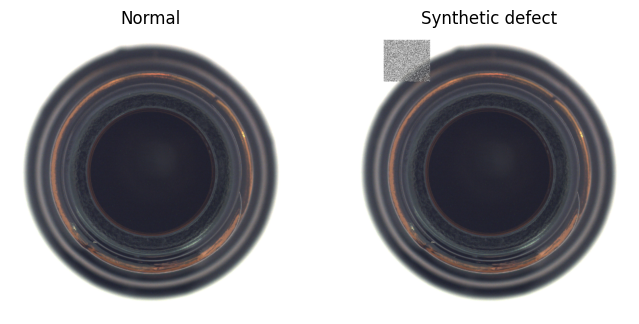

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def add_synthetic_defect(image):
    """Add a random scratch, patch, or noisy region to a PIL image."""
    image = image.convert('RGB').copy()
    w, h = image.size
    draw = ImageDraw.Draw(image, 'RGBA')
    defect_type = random.choice(['rectangle', 'scratch', 'noise'])
    x1, y1 = random.randint(0, int(w * .65)), random.randint(0, int(h * .65))
    x2, y2 = random.randint(x1 + 8, min(w, x1 + int(w * .35))), random.randint(y1 + 8, min(h, y1 + int(h * .35)))
    if defect_type == 'rectangle':
        color = random.choice([(255, 30, 30, 190), (20, 20, 20, 210), (255, 220, 0, 180)])
        draw.rectangle([x1, y1, x2, y2], fill=color)
    elif defect_type == 'scratch':
        for _ in range(random.randint(2, 5)):
            draw.line([x1, y1 + random.randint(0, max(1, y2-y1)), x2, y1 + random.randint(0, max(1, y2-y1))], fill=(255, 255, 255, 230), width=random.randint(1, 3))
    else:
        patch = Image.effect_noise((max(2, x2-x1), max(2, y2-y1)), random.randint(80, 180)).convert('L').convert('RGBA')
        patch.putalpha(170)
        image.paste(patch, (x1, y1), patch)
    return image

class SyntheticMVTecDataset(Dataset):
    def __init__(self, paths, transform, anomaly_probability=0.5):
        self.paths = paths
        self.transform = transform
        self.anomaly_probability = anomaly_probability
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        is_anomaly = random.random() < self.anomaly_probability
        if is_anomaly: image = add_synthetic_defect(image)
        return self.transform(image), torch.tensor(int(is_anomaly), dtype=torch.long)

class RealMVTecTestDataset(Dataset):
    def __init__(self, category_root, transform):
        self.items = []
        for defect_dir in sorted((category_root / 'test').iterdir()):
            if defect_dir.is_dir():
                label = 0 if defect_dir.name == 'good' else 1
                for p in sorted(defect_dir.glob('*')):
                    if p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}:
                        self.items.append((p, label, defect_dir.name))
        self.transform = transform
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, label, defect_name = self.items[idx]
        image = Image.open(p).convert('RGB')
        return self.transform(image), torch.tensor(label), str(p), defect_name

normal_paths = sorted((CATEGORY_ROOT / 'train' / 'good').glob('*'))
train_ds = SyntheticMVTecDataset(normal_paths, train_transform)
test_ds = RealMVTecTestDataset(CATEGORY_ROOT, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print('Normal training images:', len(normal_paths))
print('Real test images:', len(test_ds))

# Preview a normal image and a synthetic defect
sample = Image.open(normal_paths[0]).convert('RGB')
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(sample); ax[0].set_title('Normal'); ax[0].axis('off')
ax[1].imshow(add_synthetic_defect(sample)); ax[1].set_title('Synthetic defect'); ax[1].axis('off')
plt.show()

## 3. Fine-tune a pretrained ResNet-18 locally

The ImageNet-pretrained ResNet-18 provides a useful visual feature extractor. We first freeze most layers and fine-tune the final convolutional block (`layer4`) plus the new binary classification head. This reduces training time and memory use on the edge device.

In [6]:
def build_model():
    try:
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        print('Loaded ImageNet-pretrained ResNet-18.')
    except Exception as exc:
        print('Pretrained weights unavailable; using random initialization:', exc)
        model = models.resnet18(weights=None)
    for p in model.parameters(): p.requires_grad = False
    for p in model.layer4.parameters(): p.requires_grad = True
    model.fc = nn.Sequential(
        nn.Dropout(0.25),
        nn.Linear(model.fc.in_features, 2)
    )
    return model.to(DEVICE)

model = build_model()
criterion = nn.CrossEntropyLoss()
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print('Trainable parameters:', sum(p.numel() for p in trainable_params))

Loaded ImageNet-pretrained ResNet-18.
Trainable parameters: 8394754


  0%|          | 0/14 [00:00<?, ?it/s]

Epoch 01/8 | loss=0.7036 | synthetic-train accuracy=0.6029


  0%|          | 0/14 [00:00<?, ?it/s]

Epoch 02/8 | loss=0.6039 | synthetic-train accuracy=0.6890


  0%|          | 0/14 [00:00<?, ?it/s]

...

Epoch 06/8 | loss=0.4473 | synthetic-train accuracy=0.8182


  0%|          | 0/14 [00:00<?, ?it/s]

Epoch 07/8 | loss=0.4006 | synthetic-train accuracy=0.8612


  0%|          | 0/14 [00:00<?, ?it/s]

Epoch 08/8 | loss=0.3894 | synthetic-train accuracy=0.8421
Training time: 0.20 minutes


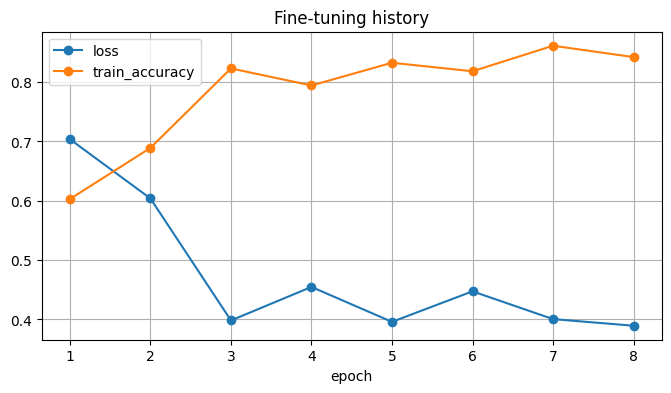

In [7]:
def train_one_epoch(model, loader):
    model.train(); running_loss = 0.0; correct = 0; total = 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item(); total += x.size(0)
    return running_loss / total, correct / total

history = []
best_state = None; best_train_acc = -1
start_train = time.perf_counter()
for epoch in range(EPOCHS):
    loss, acc = train_one_epoch(model, train_loader)
    scheduler.step()
    history.append({'epoch': epoch + 1, 'loss': loss, 'train_accuracy': acc})
    if acc > best_train_acc:
        best_train_acc = acc; best_state = copy.deepcopy(model.state_dict())
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | loss={loss:.4f} | synthetic-train accuracy={acc:.4f}')
train_seconds = time.perf_counter() - start_train
model.load_state_dict(best_state)
print(f'Training time: {train_seconds/60:.2f} minutes')
pd.DataFrame(history).plot(x='epoch', y=['loss', 'train_accuracy'], marker='o', figsize=(8, 4), title='Fine-tuning history'); plt.grid(); plt.show()

## 4. Evaluate on real MVTec defects

This is the important evaluation: the model was trained using normal images and synthetic defects, but the metrics below are calculated on the real MVTec test images.

In [8]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval(); y_true, y_pred, y_score, paths, names = [], [], [], [], []
    latency = []
    for x, y, p, n in loader:
        x = x.to(DEVICE)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter(); logits = model(x)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        latency.append((time.perf_counter() - t0) / x.size(0))
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        y_true.extend(y.numpy().tolist()); y_pred.extend((prob >= 0.5).astype(int).tolist()); y_score.extend(prob.tolist())
        paths.extend(list(p)); names.extend(list(n))
    return np.array(y_true), np.array(y_pred), np.array(y_score), paths, names, float(np.mean(latency) * 1000)

y_true, y_pred, y_score, test_paths, defect_names, avg_latency_ms = predict_loader(model, test_loader)
metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'precision': precision_score(y_true, y_pred, zero_division=0),
    'recall': recall_score(y_true, y_pred, zero_division=0),
    'f1': f1_score(y_true, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_true, y_score),
    'avg_batch1_latency_ms': avg_latency_ms,
}
print(pd.Series(metrics).round(4))
print('\nClassification report:\n', classification_report(y_true, y_pred, target_names=['normal', 'anomaly'], zero_division=0))
print('Confusion matrix:\n', confusion_matrix(y_true, y_pred))

accuracy                 0.9277
precision                1.0000
recall                   0.9048
f1                       0.9500
roc_auc                  0.9889
avg_batch1_latency_ms    0.4596
dtype: float64

Classification report:
               precision    recall  f1-score   support

      normal       0.77      1.00      0.87        20
     anomaly       1.00      0.90      0.95        63

    accuracy                           0.93        83
   macro avg       0.88      0.95      0.91        83
weighted avg       0.94      0.93      0.93        83

Confusion matrix:
 [[20  0]
 [ 6 57]]


In [9]:
# Metrics by real defect type
results = pd.DataFrame({
    'path': test_paths, 'defect_type': defect_names, 'true_label': y_true,
    'predicted_label': y_pred, 'anomaly_probability': y_score
})
summary = results.groupby('defect_type').agg(
    samples=('true_label', 'size'),
    mean_anomaly_probability=('anomaly_probability', 'mean'),
    predicted_anomaly_rate=('predicted_label', 'mean')
).sort_values('mean_anomaly_probability', ascending=False)
display(summary.round(3))
results.to_csv(f'{CATEGORY}_predictions.csv', index=False)
torch.save({'model_state_dict': model.state_dict(), 'category': CATEGORY, 'image_size': IMAGE_SIZE, 'metrics': metrics}, f'{CATEGORY}_resnet18_finetuned.pt')
print('Saved predictions and model checkpoint.')

,samples,mean_anomaly_probability,predicted_anomaly_rate
defect_type,,,
broken_large,20,0.975,1.000
broken_small,22,0.850,0.955
contamination,21,0.795,0.762
good,20,0.149,0.000


Saved predictions and model checkpoint.


## 5. Visualize an anomaly decision

The heatmap below uses Grad-CAM from the fine-tuned ResNet-18. It shows which image regions contributed to the anomaly prediction.

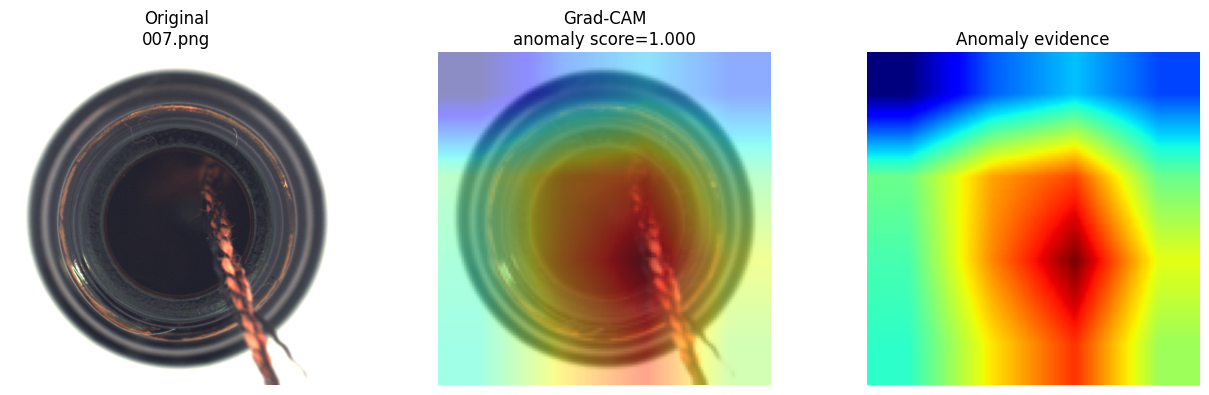

In [10]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.target_layer = target_layer
        self.activations = None; self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
    def _save_activation(self, module, inp, out): self.activations = out
    def _save_gradient(self, module, grad_in, grad_out): self.gradients = grad_out[0]
    def __call__(self, x, class_idx=1):
        self.model.zero_grad(set_to_none=True); logits = self.model(x)
        logits[:, class_idx].sum().backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True).relu()
        cam = torch.nn.functional.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy(); cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return logits.softmax(1)[0, class_idx].item(), cam

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1); std = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1,2,0).numpy()

model.eval()
cam_generator = GradCAM(model, model.layer4[-1])
display_idx = int(np.argmax(y_score))
raw = Image.open(test_paths[display_idx]).convert('RGB')
x, _, _, _ = test_ds[display_idx]
x_batch = x.unsqueeze(0).to(DEVICE).requires_grad_(True)
score, cam = cam_generator(x_batch, class_idx=1)
rgb = denormalize(x)
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(raw); ax[0].set_title(f'Original\n{Path(test_paths[display_idx]).name}'); ax[0].axis('off')
ax[1].imshow(rgb); ax[1].imshow(cam, cmap='jet', alpha=0.45); ax[1].set_title(f'Grad-CAM\nanomaly score={score:.3f}'); ax[1].axis('off')
ax[2].imshow(cam, cmap='jet'); ax[2].set_title('Anomaly evidence'); ax[2].axis('off')
plt.tight_layout(); plt.show()

## 6. Test one new image locally

Set `SINGLE_IMAGE_PATH` to an image from the MVTec test folder or a camera snapshot.

In [11]:
SINGLE_IMAGE_PATH = test_paths[display_idx]  # Replace with your own image path

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    x = eval_transform(image).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probability = torch.softmax(model(x), dim=1)[0, 1].item()
    label = 'ANOMALOUS' if probability >= 0.5 else 'NORMAL'
    return {'path': str(image_path), 'prediction': label, 'anomaly_probability': round(probability, 4), 'latency_ms': round(avg_latency_ms, 2)}

print(predict_image(SINGLE_IMAGE_PATH))

{'path': '/home/hp14/jupyterlab/mvtec_anomaly_detection/bottle/test/contamination/007.png', 'prediction': 'ANOMALOUS', 'anomaly_probability': 1.0, 'latency_ms': 0.46}


## 7. What to present

### Problem
Industrial defects are difficult to inspect consistently, and sending images to a cloud service can create privacy, latency, and connectivity concerns.

### Method
We fine-tuned an ImageNet-pretrained ResNet-18 locally on the HP edge system. The model learned normal and synthetic-defect patterns, then was evaluated on real MVTec defects.

### Edge advantage
The complete inference pipeline runs locally, so images remain on the device and predictions do not depend on an internet connection.

### Results slide
Report the values printed in the metrics cell: ROC-AUC, F1, recall, precision, average latency, and training time. Include the Grad-CAM image and one screenshot of the prediction output.

### Limitation
Synthetic defects do not represent every real defect. Future work should collect images from the actual production environment and fine-tune with real labeled samples.

In [12]:
# Install the local language-model dependencies for the inspection agent.
%pip install -q "transformers>=4.45" accelerate sentencepiece huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [13]:
# Check that the trained ResNet baseline and test image are available.
required_objects = [
    "model",
    "DEVICE",
    "CATEGORY",
    "eval_transform",
    "test_paths",
    "y_score",
    "SINGLE_IMAGE_PATH",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

print("Missing objects:", missing_objects)
print("Category:", CATEGORY if "CATEGORY" in globals() else "Not defined")
print("Vision device:", DEVICE if "DEVICE" in globals() else "Not defined")
print("Number of test images:", len(test_paths) if "test_paths" in globals() else 0)

assert not missing_objects, (
    "Run the original notebook cells from the beginning before continuing."
)
assert len(test_paths) > 0, "No MVTec test images were found."

print("Vision baseline check passed.")

Missing objects: []
Category: bottle
Vision device: cuda
Number of test images: 83
Vision baseline check passed.


In [14]:
# Load Qwen2.5-3B-Instruct locally on the HP ZGX Nano.
import os
from transformers import AutoModelForCausalLM, AutoTokenizer

LLM_ID = os.environ.get(
    "NANOINSPECT_LLM_ID",
    "Qwen/Qwen2.5-3B-Instruct"
)

HF_TOKEN = os.environ.get("HF_TOKEN")

tokenizer_kwargs = {
    "trust_remote_code": True
}

model_kwargs = {
    "trust_remote_code": True
}

if HF_TOKEN:
    tokenizer_kwargs["token"] = HF_TOKEN
    model_kwargs["token"] = HF_TOKEN

if DEVICE.type == "cuda":
    model_kwargs["device_map"] = "auto"

    bf16_supported = getattr(
        torch.cuda,
        "is_bf16_supported",
        lambda: False
    )()

    model_kwargs["torch_dtype"] = (
        torch.bfloat16
        if bf16_supported
        else torch.float16
    )

llm_tokenizer = AutoTokenizer.from_pretrained(
    LLM_ID,
    **tokenizer_kwargs
)

if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token

llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_ID,
    **model_kwargs
)

llm_model.eval()

print("Loaded LLM:", LLM_ID)
print(
    "LLM device:",
    llm_model.get_input_embeddings().weight.device
)
print("HF token supplied:", bool(HF_TOKEN))

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Loaded LLM: Qwen/Qwen2.5-3B-Instruct
LLM device: cuda:0
HF token supplied: False


In [15]:
# Verify that the local LLM can generate a response without using a cloud API.
import json
import re

def generate_local_llm(messages, max_new_tokens=160):
    prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )

    input_device = (
        llm_model
        .get_input_embeddings()
        .weight
        .device
    )

    inputs = {
        key: value.to(input_device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        generated = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=llm_tokenizer.pad_token_id
        )

    prompt_length = inputs["input_ids"].shape[1]
    new_tokens = generated[0][prompt_length:]

    return llm_tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()


def parse_json_object(text):
    match = re.search(
        r"\{.*\}",
        str(text),
        flags=re.DOTALL
    )

    if not match:
        return {}

    try:
        parsed = json.loads(match.group(0))
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}


test_messages = [
    {
        "role": "system",
        "content": (
            "Return JSON only with keys status and message."
        )
    },
    {
        "role": "user",
        "content": (
            "Confirm that the local inspection agent is ready."
        )
    }
]

test_llm_output = generate_local_llm(
    test_messages,
    max_new_tokens=60
)

print("Local LLM output:")
print(test_llm_output)

assert len(test_llm_output) > 0
print("Local LLM generation check passed.")

Local LLM output:
{
  "status": "success",
  "message": "Local inspection agent is confirmed to be ready."
}
Local LLM generation check passed.


In [16]:
# Define local tools for reinspection, SOP lookup, batch history, and severity.
from PIL import ImageEnhance

def infer_pil_image(image, source_name):
    image = image.convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    model.eval()

    with torch.inference_mode():
        logits = model(tensor)
        probability = torch.softmax(
            logits,
            dim=1
        )[0, 1].item()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    latency_ms = (
        time.perf_counter() - start_time
    ) * 1000

    label = (
        "ANOMALOUS"
        if probability >= 0.5
        else "NORMAL"
    )

    return {
        "source": str(source_name),
        "prediction": label,
        "anomaly_probability": round(
            float(probability),
            4
        ),
        "latency_ms": round(
            float(latency_ms),
            3
        )
    }


def run_vision_inference(image_path):
    image = Image.open(image_path).convert("RGB")
    return infer_pil_image(image, image_path)


def tool_reinspect_image(image_path):
    image = Image.open(image_path).convert("RGB")

    width, height = image.size
    crop_side = int(min(width, height) * 0.75)

    left = max((width - crop_side) // 2, 0)
    top = max((height - crop_side) // 2, 0)

    center_crop = image.crop(
        (
            left,
            top,
            left + crop_side,
            top + crop_side
        )
    )

    contrast_view = ImageEnhance.Contrast(
        image
    ).enhance(1.35)

    views = [
        infer_pil_image(image, "original"),
        infer_pil_image(center_crop, "center_crop"),
        infer_pil_image(
            contrast_view,
            "contrast_enhanced"
        )
    ]

    probabilities = [
        item["anomaly_probability"]
        for item in views
    ]

    mean_probability = float(
        np.mean(probabilities)
    )

    anomaly_votes = sum(
        item["prediction"] == "ANOMALOUS"
        for item in views
    )

    return {
        "tool": "reinspect_image",
        "views": views,
        "mean_anomaly_probability": round(
            mean_probability,
            4
        ),
        "anomaly_votes": anomaly_votes,
        "agreement": round(
            anomaly_votes / len(views),
            3
        )
    }


SOP_LIBRARY = {
    "default": {
        "low": (
            "Release the item after a quick visual check."
        ),
        "medium": (
            "Hold the item and perform a second inspection."
        ),
        "high": (
            "Reject the item and inspect the current batch."
        )
    },
    "bottle": {
        "low": (
            "Release the bottle after checking the surface."
        ),
        "medium": (
            "Hold the bottle and inspect the cap, label, and surface."
        ),
        "high": (
            "Reject the bottle and inspect the current bottle batch."
        )
    }
}


def tool_lookup_defect_sop(category, severity):
    policy = SOP_LIBRARY.get(
        str(category),
        SOP_LIBRARY["default"]
    )

    return {
        "tool": "lookup_defect_sop",
        "category": str(category),
        "severity": str(severity),
        "recommended_action": policy.get(
            str(severity),
            policy["medium"]
        )
    }


BATCH_HISTORY = {
    "DEMO-BATCH-001": {
        "items_inspected": 20,
        "anomalies_found": 2,
        "previous_pattern": (
            "occasional surface variation"
        )
    },
    "DEMO-BATCH-002": {
        "items_inspected": 20,
        "anomalies_found": 0,
        "previous_pattern": (
            "no repeated defect pattern"
        )
    }
}


def tool_check_quality_history(batch_id):
    history = BATCH_HISTORY.get(
        str(batch_id),
        {
            "items_inspected": 0,
            "anomalies_found": 0,
            "previous_pattern": (
                "no local history available"
            )
        }
    )

    return {
        "tool": "check_quality_history",
        "batch_id": str(batch_id),
        **history
    }


def tool_calculate_severity(
    initial_evidence,
    reinspection_result
):
    initial_probability = float(
        initial_evidence["anomaly_probability"]
    )

    repeated_probability = float(
        reinspection_result.get(
            "mean_anomaly_probability",
            initial_probability
        )
    )

    agreement = float(
        reinspection_result.get(
            "agreement",
            0.0
        )
    )

    if (
        repeated_probability >= 0.85
        and agreement >= 0.66
    ):
        severity = "high"
    elif repeated_probability >= 0.50:
        severity = "medium"
    else:
        severity = "low"

    return {
        "tool": "calculate_severity",
        "severity": severity,
        "initial_probability": round(
            initial_probability,
            4
        ),
        "reinspection_probability": round(
            repeated_probability,
            4
        ),
        "view_agreement": round(
            agreement,
            3
        )
    }

In [17]:
# Check the deterministic local tools before involving the language model.
tool_test_path = str(SINGLE_IMAGE_PATH)

initial_tool_output = run_vision_inference(
    tool_test_path
)

reinspection_tool_output = tool_reinspect_image(
    tool_test_path
)

severity_tool_output = tool_calculate_severity(
    initial_tool_output,
    reinspection_tool_output
)

sop_tool_output = tool_lookup_defect_sop(
    CATEGORY,
    severity_tool_output["severity"]
)

history_tool_output = tool_check_quality_history(
    "DEMO-BATCH-001"
)

tool_test_output = {
    "initial": initial_tool_output,
    "reinspection": reinspection_tool_output,
    "severity": severity_tool_output,
    "sop": sop_tool_output,
    "quality_history": history_tool_output
}

print(json.dumps(tool_test_output, indent=2))

assert reinspection_tool_output["tool"] == (
    "reinspect_image"
)

assert sop_tool_output["tool"] == (
    "lookup_defect_sop"
)

assert history_tool_output["tool"] == (
    "check_quality_history"
)

assert severity_tool_output["severity"] in {
    "low",
    "medium",
    "high"
}

print("All local tool checks passed.")

{
  "initial": {
    "source": "/home/hp14/jupyterlab/mvtec_anomaly_detection/bottle/test/contamination/007.png",
    "prediction": "ANOMALOUS",
    "anomaly_probability": 1.0,
    "latency_ms": 24.992
  },
  "reinspection": {
    "tool": "reinspect_image",
    "views": [
      {
        "source": "original",
        "prediction": "ANOMALOUS",
        "anomaly_probability": 1.0,
        "latency_ms": 1.808
      },
      {
        "source": "center_crop",
        "prediction": "ANOMALOUS",
        "anomaly_probability": 0.9999,
        "latency_ms": 1.628
      },
      {
        "source": "contrast_enhanced",
        "prediction": "ANOMALOUS",
        "anomaly_probability": 1.0,
        "latency_ms": 1.554
      }
    ],
    "mean_anomaly_probability": 1.0,
    "anomaly_votes": 3,
    "agreement": 1.0
  },
  "severity": {
    "tool": "calculate_severity",
    "severity": "high",
    "initial_probability": 1.0,
    "reinspection_probability": 1.0,
    "view_agreement": 1.0
  },
  "sop"

In [18]:
# Define the Qwen agent that selects tools and creates the inspection report.
AGENT_SYSTEM_PROMPT = """
You are NanoInspect, a local industrial quality-inspection agent.

The vision model has already analyzed the image.
You may choose exactly one action:

reinspect_image
calculate_severity
lookup_defect_sop
check_quality_history
finalize

Use tools when they reduce uncertainty.

Return JSON only:
{
  "action": "...",
  "reason": "..."
}

Do not invent visual evidence.
"""

ALLOWED_ACTIONS = {
    "reinspect_image",
    "calculate_severity",
    "lookup_defect_sop",
    "check_quality_history",
    "finalize"
}


def fallback_action(state):
    completed = set(
        state["tool_results"].keys()
    )

    if "reinspect_image" not in completed:
        return "reinspect_image"

    if "calculate_severity" not in completed:
        return "calculate_severity"

    if "lookup_defect_sop" not in completed:
        return "lookup_defect_sop"

    if "check_quality_history" not in completed:
        return "check_quality_history"

    return "finalize"


def choose_next_action(state):
    compact_state = {
        "category": state["category"],
        "vision_evidence": state[
            "vision_evidence"
        ],
        "tool_results": state[
            "tool_results"
        ],
        "tools_already_called": list(
            state["tool_results"].keys()
        )
    }

    messages = [
        {
            "role": "system",
            "content": AGENT_SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": json.dumps(
                compact_state,
                indent=2
            )
        }
    ]

    raw_output = generate_local_llm(
        messages,
        max_new_tokens=100
    )

    parsed = parse_json_object(raw_output)

    action = str(
        parsed.get("action", "")
    ).strip().lower()

    if action not in ALLOWED_ACTIONS:
        action = fallback_action(state)

    completed_count = len(
        state["tool_results"]
    )

    if (
        action == "finalize"
        and completed_count < 4
    ):
        action = fallback_action(state)

    return {
        "action": action,
        "reason": parsed.get(
            "reason",
            "Selected by the local agent."
        ),
        "raw_output": raw_output
    }


def execute_agent_tool(action, state):
    image_path = state["image_path"]

    if action == "reinspect_image":
        return tool_reinspect_image(
            image_path
        )

    if action == "calculate_severity":
        return tool_calculate_severity(
            state["vision_evidence"],
            state["tool_results"].get(
                "reinspect_image",
                {}
            )
        )

    if action == "lookup_defect_sop":
        severity = state[
            "tool_results"
        ].get(
            "calculate_severity",
            {"severity": "medium"}
        )["severity"]

        return tool_lookup_defect_sop(
            state["category"],
            severity
        )

    if action == "check_quality_history":
        return tool_check_quality_history(
            state["batch_id"]
        )

    raise ValueError(
        "Unknown agent action: " + str(action)
    )


def build_final_report(state):
    context = {
        "category": state["category"],
        "vision_evidence": state[
            "vision_evidence"
        ],
        "tool_results": state[
            "tool_results"
        ],
        "tool_trace": state[
            "tool_trace"
        ]
    }

    report_messages = [
        {
            "role": "system",
            "content": (
                "You are NanoInspect. Create a concise "
                "quality-control report. Return JSON only "
                "with keys: decision, severity, "
                "defect_summary, evidence, "
                "recommended_action."
            )
        },
        {
            "role": "user",
            "content": json.dumps(
                context,
                indent=2
            )
        }
    ]

    raw_output = generate_local_llm(
        report_messages,
        max_new_tokens=180
    )

    parsed = parse_json_object(
        raw_output
    )

    severity = state[
        "tool_results"
    ].get(
        "calculate_severity",
        {"severity": "medium"}
    ).get(
        "severity",
        "medium"
    )

    probability = float(
        state["tool_results"].get(
            "calculate_severity",
            {
                "reinspection_probability":
                    state["vision_evidence"][
                        "anomaly_probability"
                    ]
            }
        ).get(
            "reinspection_probability",
            state["vision_evidence"][
                "anomaly_probability"
            ]
        )
    )

    if probability >= 0.85:
        fallback_decision = "reject"
    elif probability >= 0.50:
        fallback_decision = "manual_review"
    else:
        fallback_decision = "accept"

    decision = str(
        parsed.get(
            "decision",
            fallback_decision
        )
    ).lower()

    if decision not in {
        "accept",
        "reject",
        "manual_review"
    }:
        decision = fallback_decision

    severity = str(
        parsed.get(
            "severity",
            severity
        )
    ).lower()

    if severity not in {
        "low",
        "medium",
        "high"
    }:
        severity = "medium"

    return {
        "decision": decision,
        "severity": severity,
        "defect_summary": parsed.get(
            "defect_summary",
            "Visual anomaly assessment generated locally."
        ),
        "evidence": parsed.get(
            "evidence",
            [state["vision_evidence"]]
        ),
        "recommended_action": parsed.get(
            "recommended_action",
            "Follow the local quality-control SOP."
        ),
        "raw_output": raw_output
    }


def run_inspection_agent(
    image_path,
    category,
    batch_id="DEMO-BATCH-001",
    max_steps=6
):
    state = {
        "image_path": str(image_path),
        "category": str(category),
        "batch_id": str(batch_id),
        "vision_evidence": run_vision_inference(
            image_path
        ),
        "tool_results": {},
        "tool_trace": []
    }

    for step in range(max_steps):
        action_choice = choose_next_action(
            state
        )

        action = action_choice["action"]

        if action == "finalize":
            state["tool_trace"].append({
                "step": step + 1,
                "action": "finalize",
                "reason": action_choice["reason"]
            })
            break

        if action in state["tool_results"]:
            action = fallback_action(state)

        if action == "finalize":
            break

        tool_output = execute_agent_tool(
            action,
            state
        )

        state["tool_results"][action] = (
            tool_output
        )

        state["tool_trace"].append({
            "step": step + 1,
            "action": action,
            "reason": action_choice["reason"],
            "tool_output": tool_output
        })

    state["report"] = build_final_report(
        state
    )

    return state

In [19]:
# Run the complete local inspection agent on one held-out MVTec image.
agent_result = run_inspection_agent(
    SINGLE_IMAGE_PATH,
    CATEGORY,
    batch_id="DEMO-BATCH-001"
)

display(
    pd.DataFrame(
        [{
            "image": agent_result["image_path"],
            "category": agent_result["category"],
            "vision_prediction": agent_result[
                "vision_evidence"
            ]["prediction"],
            "vision_probability": agent_result[
                "vision_evidence"
            ]["anomaly_probability"],
            "decision": agent_result[
                "report"
            ]["decision"],
            "severity": agent_result[
                "report"
            ]["severity"],
            "tool_calls": len(
                agent_result["tool_trace"]
            )
        }]
    )
)

print("Agent tool trace:")
print(
    json.dumps(
        agent_result["tool_trace"],
        indent=2
    )
)

print("Final local inspection report:")
print(
    json.dumps(
        agent_result["report"],
        indent=2
    )
)

,image,category,vision_prediction,vision_probability,decision,severity,tool_calls
0,/home/hp14/jupyterlab/mvtec_anomaly_detection/...,bottle,ANOMALOUS,1.0,reject,high,5


Agent tool trace:
[
  {
    "step": 1,
    "action": "reinspect_image",
    "reason": "High anomaly probability (1.0) suggests the need for reinspection.",
    "tool_output": {
      "tool": "reinspect_image",
      "views": [
        {
          "source": "original",
          "prediction": "ANOMALOUS",
          "anomaly_probability": 1.0,
          "latency_ms": 2.77
        },
        {
          "source": "center_crop",
          "prediction": "ANOMALOUS",
          "anomaly_probability": 0.9999,
          "latency_ms": 1.776
        },
        {
          "source": "contrast_enhanced",
          "prediction": "ANOMALOUS",
          "anomaly_probability": 1.0,
          "latency_ms": 1.651
        }
      ],
      "mean_anomaly_probability": 1.0,
      "anomaly_votes": 3,
      "agreement": 1.0
    }
  },
  {
    "step": 2,
    "action": "calculate_severity",
    "reason": "Reinspection confirms anomaly and all views have high anomaly probability.",
    "tool_output": {
      "too

In [20]:
# Validate the agent loop, report schema, and zero-cloud execution claim.
required_report_keys = {
    "decision",
    "severity",
    "defect_summary",
    "evidence",
    "recommended_action"
}

report_keys = set(
    agent_result["report"].keys()
)

called_actions = {
    item["action"]
    for item in agent_result["tool_trace"]
}

print("Report keys:", sorted(report_keys))
print("Actions called:", sorted(called_actions))
print(
    "Number of tool calls:",
    len(agent_result["tool_trace"])
)
print("Raw records sent to cloud: 0")

assert required_report_keys.issubset(
    report_keys
)

assert len(
    agent_result["tool_trace"]
) >= 1

assert called_actions.intersection({
    "reinspect_image",
    "calculate_severity",
    "lookup_defect_sop",
    "check_quality_history"
})

assert agent_result["report"]["decision"] in {
    "accept",
    "reject",
    "manual_review"
}

assert agent_result["report"]["severity"] in {
    "low",
    "medium",
    "high"
}

serialized_result = json.dumps(
    agent_result,
    default=str
).lower()

assert "openai.com" not in serialized_result
assert "api.openai.com" not in serialized_result

print("Agent validation passed.")
print("All model inference and tool calls remained local.")

Report keys: ['decision', 'defect_summary', 'evidence', 'raw_output', 'recommended_action', 'severity']
Actions called: ['calculate_severity', 'check_quality_history', 'finalize', 'lookup_defect_sop', 'reinspect_image']
Number of tool calls: 5
Raw records sent to cloud: 0
Agent validation passed.
All model inference and tool calls remained local.


In [21]:
# Save the local inspection report and demo summary for the presentation.
from pathlib import Path

report_path = Path(
    f"{CATEGORY}_nanoinspect_agent_report.json"
)

summary_path = Path(
    f"{CATEGORY}_nanoinspect_demo_summary.json"
)

with report_path.open(
    "w",
    encoding="utf-8"
) as handle:
    json.dump(
        agent_result,
        handle,
        indent=2,
        default=str
    )

demo_summary = {
    "project": "NanoInspect",
    "category": str(CATEGORY),
    "vision_model": "fine-tuned ResNet-18",
    "agent_model": LLM_ID,
    "device": str(DEVICE),
    "decision": agent_result[
        "report"
    ]["decision"],
    "severity": agent_result[
        "report"
    ]["severity"],
    "vision_probability": agent_result[
        "vision_evidence"
    ]["anomaly_probability"],
    "tool_calls": len(
        agent_result["tool_trace"]
    ),
    "raw_records_sent_to_cloud": 0,
    "report_path": str(
        report_path.resolve()
    )
}

with summary_path.open(
    "w",
    encoding="utf-8"
) as handle:
    json.dump(
        demo_summary,
        handle,
        indent=2
    )

print(json.dumps(
    demo_summary,
    indent=2
))

print("Saved report:", report_path.resolve())
print("Saved summary:", summary_path.resolve())

{
  "project": "NanoInspect",
  "category": "bottle",
  "vision_model": "fine-tuned ResNet-18",
  "agent_model": "Qwen/Qwen2.5-3B-Instruct",
  "device": "cuda",
  "decision": "reject",
  "severity": "high",
  "vision_probability": 1.0,
  "tool_calls": 5,
  "raw_records_sent_to_cloud": 0,
  "report_path": "/home/hp14/jupyterlab/bottle_nanoinspect_agent_report.json"
}
Saved report: /home/hp14/jupyterlab/bottle_nanoinspect_agent_report.json
Saved summary: /home/hp14/jupyterlab/bottle_nanoinspect_demo_summary.json
